### Implementing Pollynomial Regression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

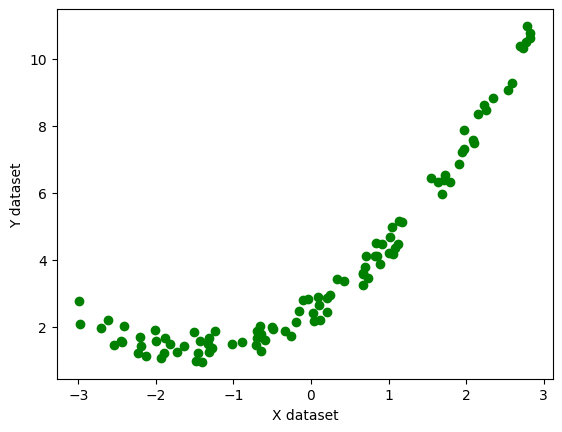

In [3]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.rand(100, 1)
plt.scatter(X, y, color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression

regression_1 = LinearRegression()

In [6]:
regression_1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
from sklearn.metrics import r2_score

score = r2_score(y_test, regression_1.predict(X_test))
print(score)

0.7295573186825475


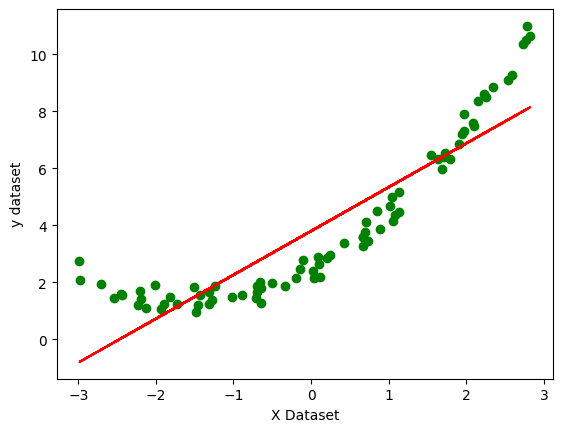

In [8]:
plt.plot(X_train, regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train, color='g')
plt.xlabel('X Dataset')
plt.ylabel('y dataset')
plt.show()

In [9]:
from sklearn.preprocessing import PolynomialFeatures

In [10]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [11]:
X_train_poly

array([[ 1.00000000e+00,  1.02152020e+00,  1.04350351e+00],
       [ 1.00000000e+00,  2.34555962e+00,  5.50164995e+00],
       [ 1.00000000e+00,  1.54658582e+00,  2.39192769e+00],
       [ 1.00000000e+00,  2.04405824e-01,  4.17817411e-02],
       [ 1.00000000e+00, -6.93702323e-01,  4.81222913e-01],
       [ 1.00000000e+00, -1.81524335e+00,  3.29510841e+00],
       [ 1.00000000e+00,  6.94235446e-01,  4.81962854e-01],
       [ 1.00000000e+00, -1.01729979e+00,  1.03489885e+00],
       [ 1.00000000e+00, -1.45677275e+00,  2.12218684e+00],
       [ 1.00000000e+00,  1.72513255e+00,  2.97608230e+00],
       [ 1.00000000e+00,  7.35029272e-01,  5.40268031e-01],
       [ 1.00000000e+00,  2.10589596e+00,  4.43479778e+00],
       [ 1.00000000e+00,  4.20190768e-01,  1.76560282e-01],
       [ 1.00000000e+00, -5.01438944e-01,  2.51441014e-01],
       [ 1.00000000e+00, -1.23333087e+00,  1.52110504e+00],
       [ 1.00000000e+00,  6.73528593e-01,  4.53640766e-01],
       [ 1.00000000e+00, -2.98444038e+00

In [12]:
regression = LinearRegression()

In [13]:
regression.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
score_2 = r2_score(y_test, regression.predict(X_test_poly))
print(score_2)

0.9896568893591743


In [15]:
regression.coef_

array([[0.        , 1.51313831, 0.48894483]])

In [16]:
regression.intercept_

array([2.46843247])

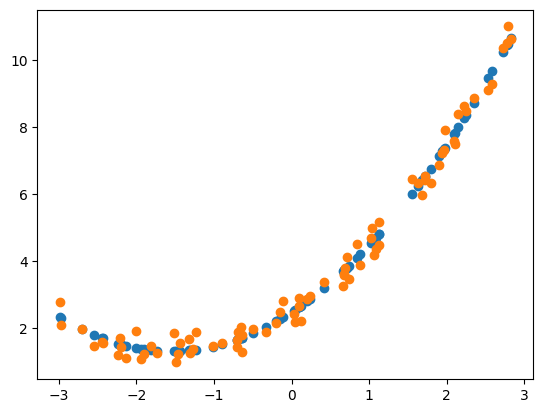

In [19]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

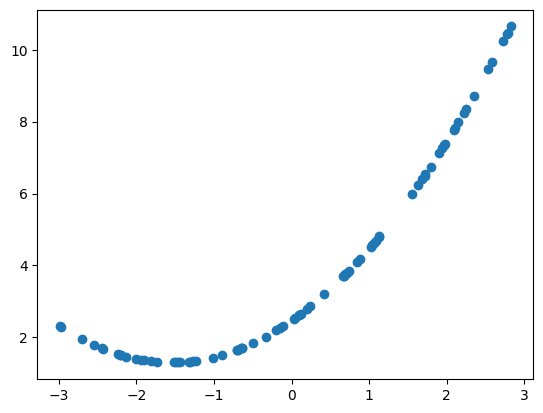

In [20]:
plt.scatter(X_train, regression.predict(X_train_poly))

In [21]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

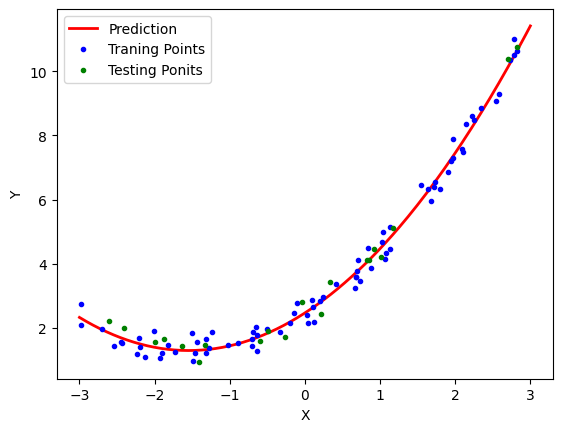

In [22]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, 'r-', linewidth=2, label='Prediction')
plt.plot(X_train, y_train, 'b.', label='Traning Points')
plt.plot(X_test, y_test, 'g.', label='Testing Ponits')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

### Pipelining

In [23]:
from sklearn.pipeline import Pipeline

In [29]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    line_reg = LinearRegression()
    poly_regression = Pipeline([
        ('poly_features', poly_features),
        ('line_reg', line_reg)
    ])

    poly_regression.fit(X_train, y_train)
    y_pred_new = poly_regression.predict(X_new)


    plt.plot(X_new, y_pred_new,'r', label="Degree" + str(degree), linewidth=3)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4, 4, 0, 10])
    plt.show()

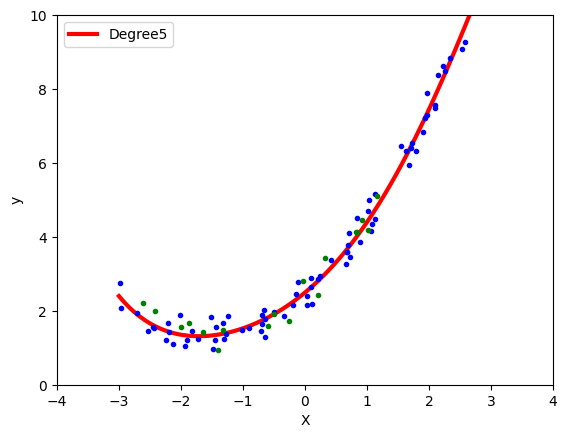

In [33]:
poly_regression(5)